In [16]:
import os
import time
import random
import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import deque
from gymnasium.wrappers import AtariPreprocessing
from PIL import Image

In [17]:
!pip install -q gymnasium[atari] ale-py autorom
os.makedirs("/root/.ale", exist_ok=True)
!AutoROM --accept-license --install-dir /root/.ale
os.environ["ALE_ROM_PATH"] = "/root/.ale"

envs = sorted([spec.id for spec in gym.envs.registry.values() if "Breakout" in spec.id])
print("Breakout environments:", envs)

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/root/.ale

Existing ROMs will be overwritten.
Breakout environments: ['ALE/Breakout-ram-v5', 'ALE/Breakout-v5', 'Breakout-ram-v0', 'Breakout-ram-v4', 'Breakout-ramDeterministic-v0', 'Breakout-ramDeterministic-v4', 'Breakout-ramNoFrameskip-v0', 'Breakout-ramNoFrameskip-v4', 'Breakout-v0', 'Breakout-v4', 'BreakoutDeterministic-v0', 'BreakoutDeterministic-v4', 'BreakoutNoFrameskip-v0', 'BreakoutNoFrameskip-v4']


Using device: cpu
Episode 0 | Reward: 3.0 | Avg per life: 0.60 | Eps: 1.00 | Loss: 0.0000
Episode 10 | Reward: 0.0 | Avg per life: 0.00 | Eps: 0.98 | Loss: 0.0000
Episode 20 | Reward: 2.0 | Avg per life: 0.40 | Eps: 0.96 | Loss: 0.0000
Episode 30 | Reward: 2.0 | Avg per life: 0.40 | Eps: 0.94 | Loss: 0.0000
Episode 40 | Reward: 0.0 | Avg per life: 0.00 | Eps: 0.92 | Loss: 0.0000
Episode 50 | Reward: 1.0 | Avg per life: 0.20 | Eps: 0.90 | Loss: 0.0044
Episode 60 | Reward: 5.0 | Avg per life: 1.00 | Eps: 0.88 | Loss: 0.0035
Episode 70 | Reward: 2.0 | Avg per life: 0.40 | Eps: 0.86 | Loss: 0.0028
Episode 80 | Reward: 1.0 | Avg per life: 0.20 | Eps: 0.84 | Loss: 0.0026
Episode 90 | Reward: 0.0 | Avg per life: 0.00 | Eps: 0.82 | Loss: 0.0039
Episode 100 | Reward: 1.0 | Avg per life: 0.20 | Eps: 0.80 | Loss: 0.0038
Episode 110 | Reward: 3.0 | Avg per life: 0.60 | Eps: 0.78 | Loss: 0.0042
Episode 120 | Reward: 3.0 | Avg per life: 0.60 | Eps: 0.76 | Loss: 0.0042
Episode 130 | Reward: 0.0 | Avg

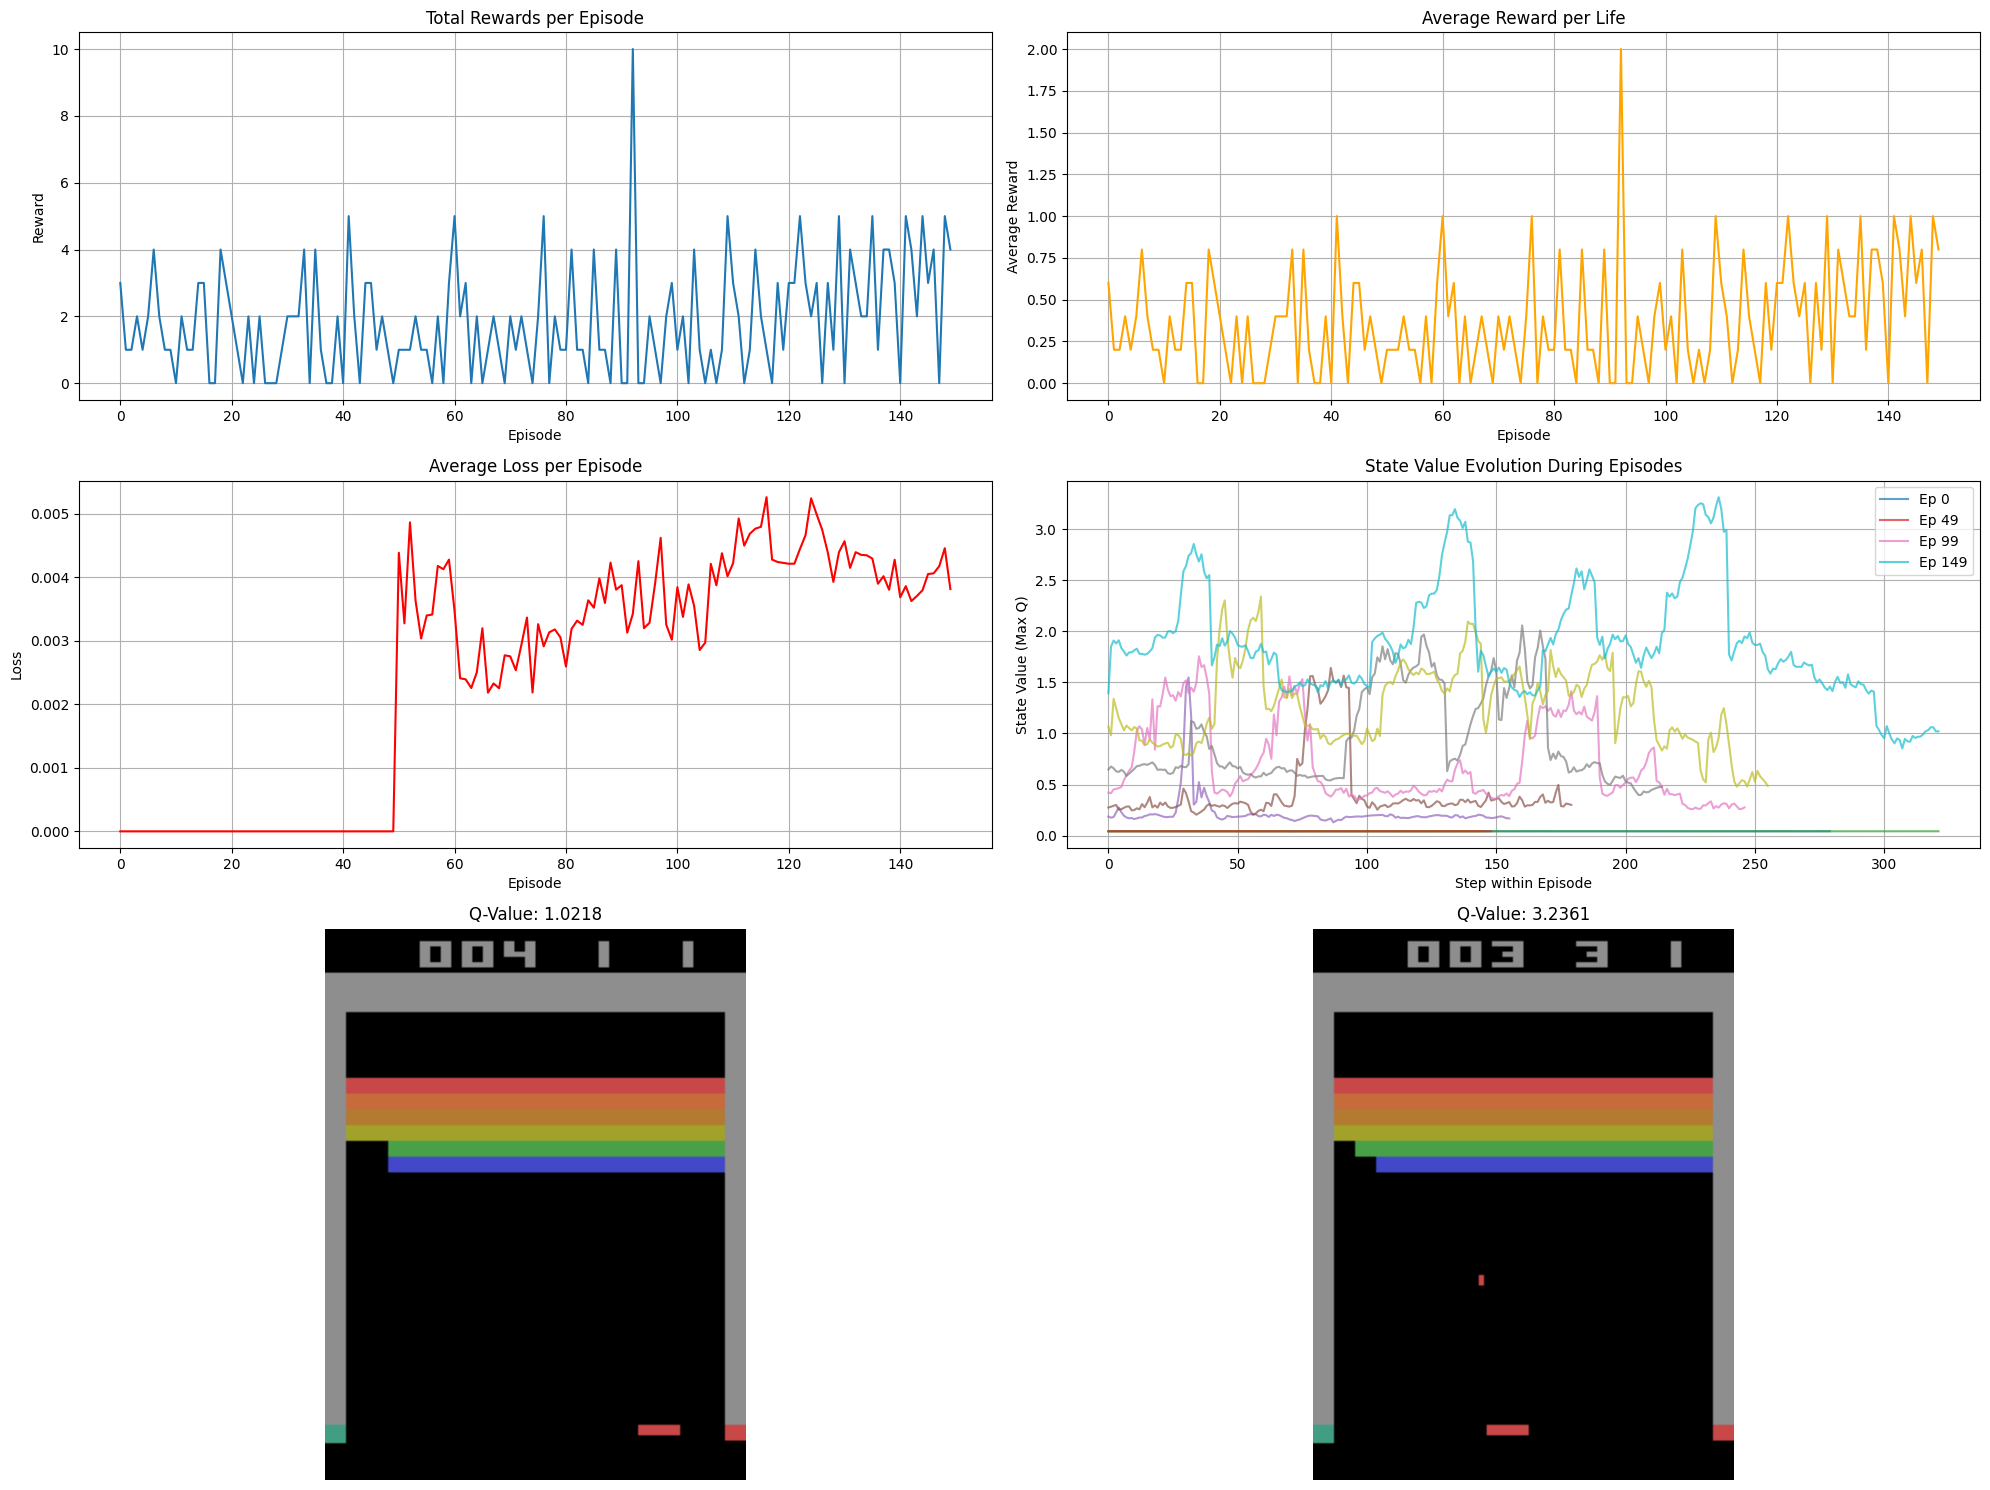

Model saved to 'breakout_dqn_model.pth'


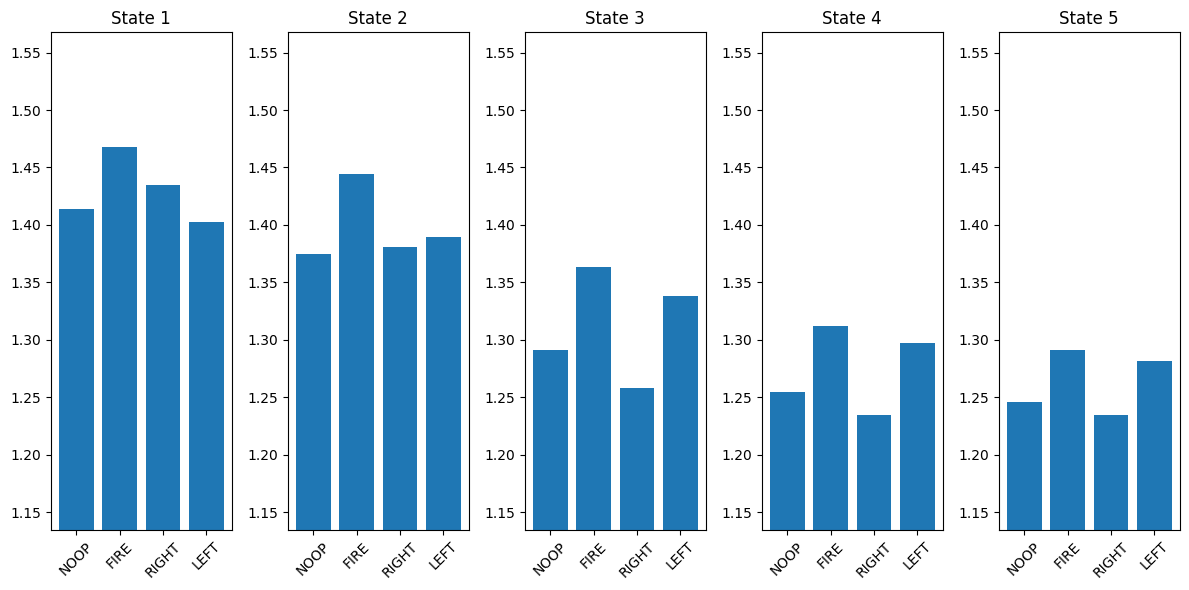

In [19]:
BATCH_SIZE = 32
LR = 0.0001
GAMMA = 0.99
MEMORY_CAPACITY = 100000
MEMORY_START_SIZE = 10000
TARGET_UPDATE_FREQ = 250
Q_NETWORK_ITERATION = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

class FrameStack(gym.Wrapper):
    def __init__(self, env, num_stack):
        super().__init__(env)
        self.num_stack = num_stack
        self.frames = deque(maxlen=num_stack)
        obs_space = env.observation_space
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0,
            shape=(num_stack, obs_space.shape[0], obs_space.shape[1]),
            dtype=np.float32
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.num_stack):
            self.frames.append(obs)
        return np.stack(self.frames, axis=0), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(obs)
        return np.stack(self.frames, axis=0), reward, terminated, truncated, info


class CNN(nn.Module):
    def __init__(self, in_channels, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 8, 4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(state).to(DEVICE),
            torch.LongTensor(action).to(DEVICE),
            torch.FloatTensor(reward).to(DEVICE),
            torch.FloatTensor(next_state).to(DEVICE),
            torch.FloatTensor(done).to(DEVICE)
        )

    def __len__(self):
        return len(self.buffer)


class DQN:
    def __init__(self, n_actions, in_channels):
        self.eval_net = CNN(in_channels, n_actions).to(DEVICE)
        self.target_net = CNN(in_channels, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.eval_net.state_dict())

        self.memory = ReplayBuffer(MEMORY_CAPACITY)
        self.optimizer = optim.Adam(self.eval_net.parameters(), lr=LR)
        self.steps = 0
        self.n_actions = n_actions
        self.losses = []

    def get_action(self, state, epsilon):
        if random.random() < epsilon:
            action = random.randrange(self.n_actions)
            # zeros as placeholder
            q_values = np.zeros(self.n_actions)
            return action, q_values

        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.eval_net(state_tensor)
            q_np = q_values.cpu().numpy()[0]
            action = q_values.argmax().item()
            return action, q_np

    def get_state_value(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_values = self.eval_net(state_tensor)
            max_q = q_values.max().item()
            q_np = q_values.cpu().numpy()[0]
            return max_q, q_np

    def update(self):
        if len(self.memory) < MEMORY_START_SIZE:
            return None

        state, action, reward, next_state, done = self.memory.sample(BATCH_SIZE)

        q_values = self.eval_net(state)
        state_action = q_values.gather(1, action.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_net(next_state).max(1)[0]
            expected = reward + GAMMA * next_q * (1 - done)

        loss = F.smooth_l1_loss(state_action, expected)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.losses.append(loss.item())

        if self.steps % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.eval_net.state_dict())

        self.steps += 1
        return loss.item()

def process_frame_for_display(frame):
    if frame is None:
        return None

    if len(frame.shape) > 3:
        frame = frame[-1]

    if len(frame.shape) == 2 or frame.shape[0] == 1:
        frame = np.repeat(frame[np.newaxis, :, :], 3, axis=0)
        frame = np.transpose(frame, (1, 2, 0))  # (H, W, C)

    if frame.max() <= 1.0:
        frame = (frame * 255).astype(np.uint8)

    return frame

# === environment ===
def setup_env(render_mode=None):
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode, frameskip=1)
    env = AtariPreprocessing(env, grayscale_obs=True, scale_obs=True, frame_skip=4)
    env = FrameStack(env, num_stack=4)
    return env

# === training ===
def train(agent, episodes=1000, log_interval=10, save_screenshots=True):
    env = setup_env(render_mode="rgb_array" if save_screenshots else None)
    n_actions = env.action_space.n

    rewards = []
    life_scores_all = []
    episode_losses = []
    state_values_over_time = []

    num_peaks_to_track = 5
    peak_states = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        epsilon = max(0.1, 1.0 - ep / 500)

        episode_losses_list = []
        episode_state_values = []
        frame_screenshots = []

        try:
            _, _, _, _, info = env.step(0)
            prev_lives = info.get('lives', 5)
        except Exception as e:
            print(f"Error getting initial lives: {e}")
            prev_lives = 5

        life_reward = 0
        life_scores = []

        step = 0

        while not done:
            rendered_frame = None
            if save_screenshots:
                try:
                    rendered_frame = env.render()
                    frame_screenshots.append(rendered_frame)
                except Exception as e:
                    print(f"Error rendering: {e}")
                    save_screenshots = False

            action, q_values = agent.get_action(state, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            max_q, _ = agent.get_state_value(state)
            episode_state_values.append(max_q)

            if len(peak_states) < num_peaks_to_track or max_q > min([v for v, _ in peak_states] + [float('-inf')]):
                if len(peak_states) >= num_peaks_to_track:
                    peak_states.remove(min(peak_states, key=lambda x: x[0]))
                if save_screenshots and rendered_frame is not None:
                    peak_states.append((max_q, process_frame_for_display(rendered_frame)))
                else:
                    peak_states.append((max_q, None))
                peak_states.sort(reverse=True, key=lambda x: x[0])

            agent.memory.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            life_reward += reward

            try:
                current_lives = info.get('lives', prev_lives)
                if current_lives < prev_lives:
                    life_scores.append(life_reward)
                    life_reward = 0
                    prev_lives = current_lives
            except Exception as e:
                print(f"Error tracking lives: {e}")

            loss = agent.update()
            if loss is not None:
                episode_losses_list.append(loss)

            step += 1

        if life_reward > 0:
            life_scores.append(life_reward)

        rewards.append(total_reward)
        life_scores_all.append(life_scores)

        if episode_losses_list:
            avg_loss = np.mean(episode_losses_list)
            episode_losses.append(avg_loss)
        else:
            episode_losses.append(0)

        state_values_over_time.append(episode_state_values)

        if ep % log_interval == 0:
            avg_life = np.mean(life_scores) if life_scores else 0
            avg_loss = np.mean(episode_losses_list) if episode_losses_list else 0
            print(f"Episode {ep} | Reward: {total_reward:.1f} | Avg per life: {avg_life:.2f} | Eps: {epsilon:.2f} | Loss: {avg_loss:.4f}")

    env.close()
    return rewards, life_scores_all, episode_losses, state_values_over_time, peak_states

# === visualization ===
def plot_training_metrics(rewards, life_scores_all, losses, state_values, peak_states=None):
    plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1.5])

    # rewards
    ax1 = plt.subplot(gs[0, 0])
    ax1.plot(rewards, label='Total Reward')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.set_title('Total Rewards per Episode')
    ax1.grid(True)

    # avg reward/life
    ax2 = plt.subplot(gs[0, 1])
    avg_life_rewards = [np.mean(life_scores) if life_scores else 0 for life_scores in life_scores_all]
    ax2.plot(avg_life_rewards, label='Avg Reward per Life', color='orange')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Average Reward')
    ax2.set_title('Average Reward per Life')
    ax2.grid(True)

    # losses
    ax3 = plt.subplot(gs[1, 0])
    ax3.plot(losses, label='Loss', color='red')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Loss')
    ax3.set_title('Average Loss per Episode')
    ax3.grid(True)

    # state values distribution over time
    ax4 = plt.subplot(gs[1, 1])
    # state values distribution heatmap
    if state_values:
        # data prep for compact visualization
        episodes_to_sample = min(len(state_values), 10)
        sampled_episodes = np.linspace(0, len(state_values)-1, episodes_to_sample, dtype=int)

        for i, ep_idx in enumerate(sampled_episodes):
            values = state_values[ep_idx]
            if values:
                ax4.plot(values, alpha=0.7, label=f'Ep {ep_idx}' if i % 3 == 0 else "")

        ax4.set_xlabel('Step within Episode')
        ax4.set_ylabel('State Value (Max Q)')
        ax4.set_title('State Value Evolution During Episodes')
        ax4.grid(True)
        if episodes_to_sample <= 10:
            ax4.legend()

    # peak state screenshots
    has_valid_frames = peak_states and any(frame is not None for _, frame in peak_states)
    if has_valid_frames:
        num_valid_frames = sum(1 for _, frame in peak_states if frame is not None)
        if num_valid_frames > 0:
            for i, (value, frame) in enumerate(peak_states):
                if frame is not None:
                    plt.subplot(gs[2, i % 2])  # Position in the grid
                    plt.imshow(frame)
                    plt.title(f'Q-Value: {value:.4f}')
                    plt.axis('off')

    plt.tight_layout()
    plt.savefig('breakout_training_visualization.png', dpi=300)
    plt.show()

# === training and visualization ===
if __name__ == "__main__":
    print(f"Using device: {DEVICE}")
    start = time.time()

    env = setup_env()
    n_actions = env.action_space.n
    state_shape = env.observation_space.shape

    agent = DQN(n_actions, state_shape[0])
    rewards, life_scores_all, losses, state_values, peak_states = train(
        agent,
        episodes=150,
        log_interval=10,
        save_screenshots=True
    )

    training_time = time.time() - start
    print(f"Total training time: {training_time:.2f} seconds")
    print(f"Final average reward (last 10 episodes): {np.mean(rewards[-10:]):.2f}")

    plot_training_metrics(rewards, life_scores_all, losses, state_values, peak_states)

    torch.save(agent.eval_net.state_dict(), 'breakout_dqn_model.pth')
    print("Model saved to 'breakout_dqn_model.pth'")

    plt.figure(figsize=(12, 6))
    states = []
    q_values = []

    test_env = setup_env()
    state, _ = test_env.reset()

    for _ in range(5):
        action = test_env.action_space.sample()
        next_state, _, terminated, truncated, _ = test_env.step(action)
        states.append(state)
        _, q_vals = agent.get_state_value(state)
        q_values.append(q_vals)
        state = next_state
        if terminated or truncated:
            state, _ = test_env.reset()

    action_names = ["NOOP", "FIRE", "RIGHT", "LEFT"]

    for i, (state, q_vals) in enumerate(zip(states, q_values)):
        plt.subplot(1, 5, i+1)
        plt.bar(action_names, q_vals)
        plt.title(f"State {i+1}")
        plt.ylim(np.min(q_values) - 0.1, np.max(q_values) + 0.1)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig('q_values_per_action.png', dpi=300)
    plt.show()

    test_env.close()